In [4]:
!pip install Pillow
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.7 MB/s  0:00:00


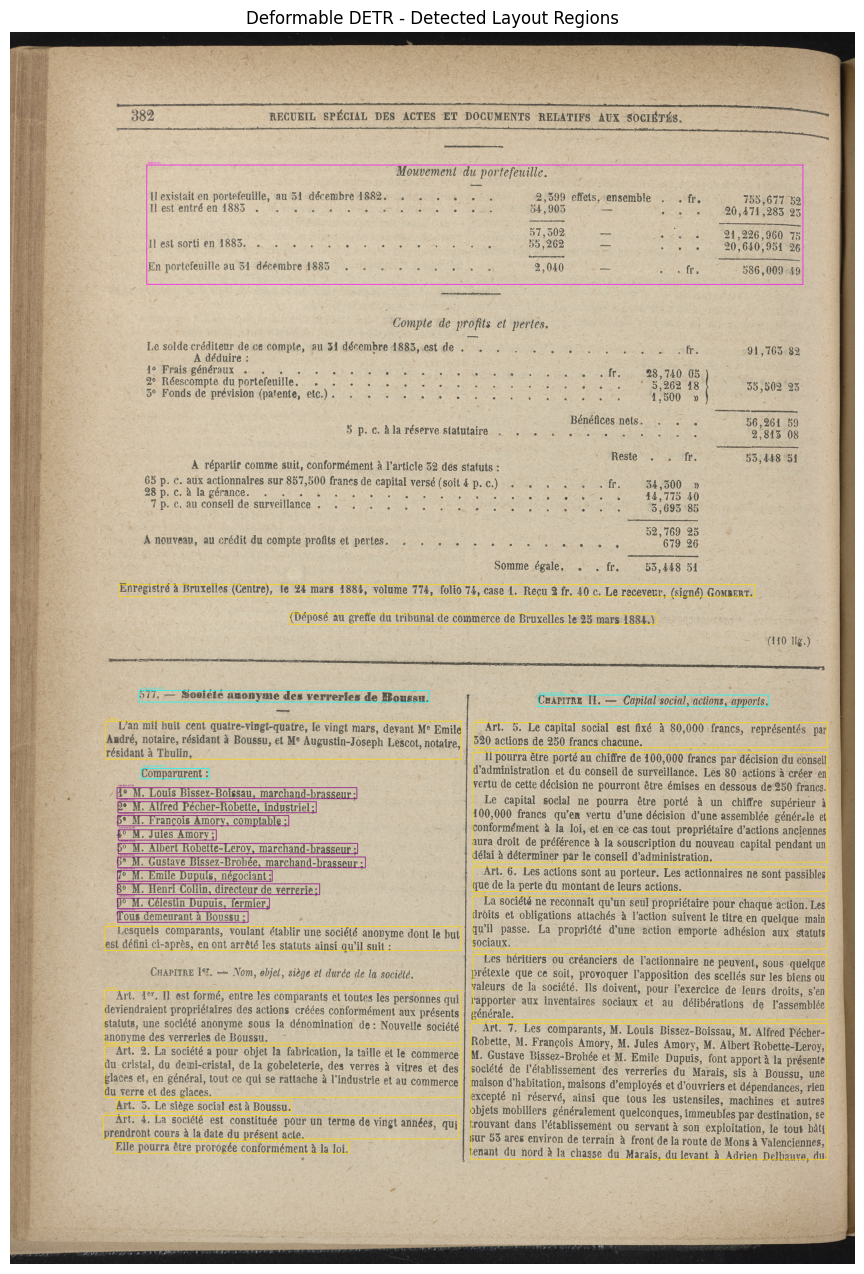

In [10]:
from transformers import AutoProcessor, DeformableDetrForObjectDetection
from PIL import Image, ImageDraw, ImageFont
import torch
import matplotlib.pyplot as plt

# 1. Load your document image
image_path = "test/test-Yves_026_None.png"
image = Image.open(image_path).convert("RGB")

# 2. Load processor and Deformable DETR model
model_id = "Aryn/deformable-detr-DocLayNet"  # or "pascalrai/Deformable-DETR-Document-Layout-Analyzer"
processor = AutoProcessor.from_pretrained(model_id)
model = DeformableDetrForObjectDetection.from_pretrained(model_id)

# 3. Inference
inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)

# 4. Post-process (match image size)
target_sizes = torch.tensor([image.size[::-1]])  # [height, width]
results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.4)[0]

# 5. Draw boxes
draw = ImageDraw.Draw(image)
id2label = model.config.id2label

COLORS = ["red", "green", "blue", "orange", "purple", "teal", "brown", "pink", "cyan", "magenta", "gold"]

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    label_text = id2label[label.item()]
    color = COLORS[label.item() % len(COLORS)]
    x0, y0, x1, y1 = box.tolist()
    draw.rectangle([x0, y0, x1, y1], outline=color, width=3)
    draw.text((x0 + 5, y0 - 15), f"{label_text} ({score:.2f})", fill=color)

# 6. Show with matplotlib
plt.figure(figsize=(12, 16))
plt.imshow(image)
plt.axis("off")
plt.title("Deformable DETR - Detected Layout Regions")
plt.show()
